### Helper Functions for Stats and Boost Parsing:

In [ ]:
import json
from collections import defaultdict
import numpy as np
import re
import pandas as pd
import subprocess
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial.distance import cdist

def extract_scoreboard_changes(path):
    """
    Given a Rocket League replay JSON (from rrrocket/boxcars),
    return a list of scoreboard-related changes (shots, saves, assists, goals),
    including both initializations and increments.
    
    Each element in the returned list is a dict with keys:
      - frame
      - time
      - actor_id
      - player_name
      - property   (e.g. MatchShots, MatchAssists)
      - value      (for initializations)
      - delta      (for increments, optional)
      - new_value  (for increments, optional)
    """

    # --------------------------
    # Load replay JSON
    # --------------------------
    with open(path, "r", encoding="utf-8") as f:
        replay = json.load(f)

    frames = replay["network_frames"]["frames"]
    objects = replay["objects"]
    net_cache = replay["net_cache"]

    # --------------------------
    # Build PRI stat stream map
    # --------------------------
    pri_entry = None
    for entry in net_cache:
        oi = entry.get("object_ind")
        if oi is not None and objects[oi] == "TAGame.PRI_TA":
            pri_entry = entry
            break

    if pri_entry is None:
        raise RuntimeError("Could not find TAGame.PRI_TA net cache in replay (PRI class).")

    pri_stream_map = {}
    for prop in pri_entry["properties"]:
        obj_ind = prop["object_ind"]
        stream_id = prop["stream_id"]
        pri_stream_map[stream_id] = objects[obj_ind]

    stat_names = ["MatchShots", "MatchAssists", "MatchGoals", "MatchSaves"]
    stat_streams = {sid: name for sid, name in pri_stream_map.items() if any(k in name for k in stat_names)}

    # --------------------------
    # Map actor_id -> player_name
    # --------------------------
    def extract_name(attr):
        if not isinstance(attr, dict):
            return None
        if "Reservation" in attr and isinstance(attr["Reservation"], dict):
            if "name" in attr["Reservation"]:
                return attr["Reservation"]["name"]
        if "String" in attr and isinstance(attr["String"], str):
            return attr["String"]
        for v in attr.values():
            if isinstance(v, dict):
                if "name" in v and isinstance(v["name"], str):
                    return v["name"]
                if "String" in v and isinstance(v["String"], str):
                    return v["String"]
            if isinstance(v, str) and v and len(v) < 64:
                return v
        return None

    actor_to_name = {}
    for frame in frames:
        for ua in frame.get("updated_actors", []):
            aid = ua.get("actor_id")
            name = extract_name(ua.get("attribute", {}))
            if name:
                actor_to_name[aid] = name

    # --------------------------
    # Collect raw stat property updates
    # --------------------------
    stat_stream_ids = set(stat_streams.keys())
    events = []  # raw stat updates

    for fi, frame in enumerate(frames):
        t = frame.get("time")
        for ua in frame.get("updated_actors", []):
            sid = ua.get("stream_id")
            if sid in stat_stream_ids:
                aid = ua.get("actor_id")
                prop = stat_streams[sid]
                attr = ua.get("attribute", {})
                val = None
                if isinstance(attr, dict):
                    for k in ("Int", "Byte", "Float"):
                        if k in attr:
                            val = attr[k]
                            break
                    if val is None:
                        def find_num(x):
                            if isinstance(x, (int, float)):
                                return x
                            if isinstance(x, dict):
                                for vv in x.values():
                                    r = find_num(vv)
                                    if r is not None:
                                        return r
                            return None
                        val = find_num(attr)
                events.append({
                    "frame": fi,
                    "time": t,
                    "actor_id": aid,
                    "player_name": actor_to_name.get(aid, f"Actor{aid}"),
                    "property": prop,
                    "value": val
                })

    # --------------------------
    # Build initializations and increments
    # --------------------------
    series = defaultdict(list)  # (actor_id, property) -> list of (frame, time, value)
    for e in events:
        key = (e["actor_id"], e["property"])
        series[key].append((e["frame"], e["time"], e["value"]))

    changes = []

    for key, vals in series.items():
        prev_val = None
        for frame, time, v in vals:
            if prev_val is None and v is not None:
                # initialization
                changes.append({
                    "frame": frame,
                    "time": time,
                    "actor_id": key[0],
                    "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                    "property": key[1],
                    "value": v,
                    "event_type": "init"
                })
            elif prev_val is not None and v is not None:
                delta = v - prev_val
                if delta != 0:
                    changes.append({
                        "frame": frame,
                        "time": time,
                        "actor_id": key[0],
                        "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                        "property": key[1],
                        "delta": delta,
                        "new_value": v,
                        "event_type": "increment"
                    })
            prev_val = v

    # --------------------------
    # Return combined list sorted by frame
    # --------------------------
    changes.sort(key=lambda x: x["frame"])
    return changes

def extract_player_boost_arrays(replay_json) -> dict[str, np.ndarray]:
    """
    Parse a Boxcars/rrrocket JSON replay and return a dict of per-player boost arrays.
    
    Each entry in the dict is {player_name: np.array}, where the array has length equal
    to the number of frames in the replay and contains the boost amount (0–255) at each frame.
    
    Handles:
      - car respawns (actor IDs change)
      - delayed PlayerReplicationInfo updates
      - forward-fills boost values across frames
    """
    
    # -------------------
    # Load JSON
    # -------------------
    # with open(replay_json_path, "r", encoding="utf-8") as f:
    #     data = json.load(f)
    data = replay_json

    frames  = data["network_frames"]["frames"]
    objects = data["objects"]
    num_frames = len(frames)

    # -------------------
    # Find relevant object indices
    # -------------------
    def find_index(substr):
        substr = substr.lower()
        return next((i for i, s in enumerate(objects) if substr in s.lower()), None)

    playername_idx = find_index("playerreplicationinfo:playername")
    playerrep_idx  = find_index("engine.pawn:playerreplicationinfo")
    vehicle_idx    = find_index("carcomponent_ta:vehicle")

    # boost property object IDs
    boost_obj_indices = [i for i, s in enumerate(objects)
                         if "carcomponent_boost" in s.lower() and
                            ("replicatedboost" in s.lower() or "currentboostamount" in s.lower())]
    if not boost_obj_indices:
        boost_obj_indices = [i for i, s in enumerate(objects)
                             if "boost" in s.lower() and "amount" in s.lower()]

    # -------------------
    # Helpers
    # -------------------
    def find_actor_field(attr):
        if isinstance(attr, dict):
            for k, v in attr.items():
                if k.lower() == "actor" and isinstance(v, int):
                    return v
                res = find_actor_field(v)
                if res is not None:
                    return res
        elif isinstance(attr, list):
            for e in attr:
                res = find_actor_field(e)
                if res is not None:
                    return res
        return None

    def extract_string(attr):
        if isinstance(attr, str):
            return attr
        if isinstance(attr, dict):
            for v in attr.values():
                s = extract_string(v)
                if s: return s
        if isinstance(attr, list):
            for e in attr:
                s = extract_string(e)
                if s: return s
        return None

    def extract_boost_amount(attr):
        if not isinstance(attr, dict):
            return None
        for k, v in attr.items():
            if isinstance(v, dict) and "boost_amount" in v:
                return float(v["boost_amount"])
            if k.lower() in ("float","double","byte","int","short") and isinstance(v,(int,float)):
                return float(v)
        if isinstance(attr, dict):
            for v in attr.values():
                amt = extract_boost_amount(v)
                if amt is not None: return amt
        if isinstance(attr, list):
            for e in attr:
                amt = extract_boost_amount(e)
                if amt is not None: return amt
        return None

    # -------------------
    # State mappings
    # -------------------
    pri_actor_to_name = {}   # stable
    car_actor_to_pri  = {}   # dynamic
    boostcomp_to_car  = {}   # dynamic

    pending = []             # buffered boosts: (frame, car_actor, amount)
    player_arrays = {}       # output

    # -------------------
    # Walk frames
    # -------------------
    for fi, frame in enumerate(frames):
        # new actors
        for na in frame.get("new_actors", []):
            obj = objects[na["object_id"]]
            if "car_ta" in obj.lower():
                car_actor_to_pri[na["actor_id"]] = None

        # updates
        for upd in frame.get("updated_actors", []):
            aid   = upd["actor_id"]
            objid = upd["object_id"]
            attr  = upd.get("attribute", {})

            if objid == playername_idx:  # Player name
                nm = extract_string(attr)
                if nm:
                    pri_actor_to_name[aid] = nm
                    if nm not in player_arrays:
                        player_arrays[nm] = np.full((num_frames,), np.nan)

            elif objid == playerrep_idx:  # Car -> PRI
                pri = find_actor_field(attr)
                if pri is not None:
                    car_actor_to_pri[aid] = pri

            elif objid == vehicle_idx:    # BoostComp -> Car
                car_actor = find_actor_field(attr)
                if car_actor is not None:
                    boostcomp_to_car[aid] = car_actor

            elif objid in boost_obj_indices or \
                 "replicatedboost" in objects[objid].lower() or \
                 "currentboostamount" in objects[objid].lower():
                amt = extract_boost_amount(attr)
                if amt is not None:
                    car_actor = boostcomp_to_car.get(aid)
                    if car_actor is not None:
                        pri = car_actor_to_pri.get(car_actor)
                        if pri is not None and pri in pri_actor_to_name:
                            pname = pri_actor_to_name[pri]
                            player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
                            player_arrays[pname][fi] = amt
                        else:
                            # buffer it until mapping known
                            pending.append((fi, car_actor, amt))

        # resolve pending
        still_pending = []
        for f, car, amt in pending:
            pri = car_actor_to_pri.get(car)
            if pri is not None and pri in pri_actor_to_name:
                pname = pri_actor_to_name[pri]
                player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
                player_arrays[pname][f] = amt
            else:
                still_pending.append((f, car, amt))
        pending = still_pending

        # clean up deleted actors
        for dead in frame.get("deleted_actors", []):
            car_actor_to_pri.pop(dead, None)
            boostcomp_to_car.pop(dead, None)

    # -------------------
    # Forward fill
    # -------------------
    for p, arr in player_arrays.items():
        last = np.nan
        for i in range(len(arr)):
            if not np.isnan(arr[i]):
                last = arr[i]
            else:
                arr[i] = last if not np.isnan(last) else np.nan

    return player_arrays

In [2]:
replay_df = pd.read_csv('test_df.csv', header=[0,1], index_col=0)
replay_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 10930 entries, 1 to 10938
Data columns (total 111 columns):
 #    Column                                Dtype  
---   ------                                -----  
 0    (brokeboy.exe, ping)                  int64  
 1    (brokeboy.exe, pos_x)                 float64
 2    (brokeboy.exe, pos_y)                 float64
 3    (brokeboy.exe, pos_z)                 float64
 4    (brokeboy.exe, vel_x)                 float64
 5    (brokeboy.exe, vel_y)                 float64
 6    (brokeboy.exe, vel_z)                 float64
 7    (brokeboy.exe, ang_vel_x)             float64
 8    (brokeboy.exe, ang_vel_y)             float64
 9    (brokeboy.exe, ang_vel_z)             float64
 10   (brokeboy.exe, throttle)              float64
 11   (brokeboy.exe, steer)                 float64
 12   (brokeboy.exe, handbrake)             object 
 13   (brokeboy.exe, rot_x)                 float64
 14   (brokeboy.exe, rot_y)                 float64
 15   (brok

/var/folders/11/n8zkztqx4gz05487nfq4vl740000gn/T/ipykernel_72937/1067861166.py:1: DtypeWarning: Columns (106) have mixed types. Specify dtype option on import or set low_memory=False.
  replay_df = pd.read_csv('test_df.csv', header=[0,1], index_col=0)


In [ ]:
RRROCKET = '/Users/marcomaluf/Desktop/Unfinished Projects/New RL/rrrocket'
REPLAY = '/Users/marcomaluf/Desktop/Unfinished Projects/New RL/temp_replay_upload_flow/63fff9b2-c623-4809-b213-6026150bb7c5.replay copy'

def run_rrrocket(command):
    try:
        result = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            universal_newlines=True,
            check=True
        )
        replay_json = json.loads(result.stdout)
    except subprocess.CalledProcessError as e:
        # Print the error output
        print(f"Error: {e}")
        print(f"Return Code: {e.returncode}")
        print("Standard Error:")
        print(e.stderr)

    return replay_json

command = [
    RRROCKET,
    "--network-parse",
    f'{REPLAY}'
]

replay_json = run_rrrocket(command)

In [4]:
player_boosts = extract_player_boost_arrays(replay_json)

In [5]:
player_boosts

{'brokeboy.exe': array([85., 85., 85., ..., 89., 89., 89.]),
 'Pulse Eva <3': array([ 85.,  85.,  85., ..., 205., 205., 205.]),
 'Jim': array([85., 85., 85., ...,  4.,  4.,  4.]),
 'Razor_NA': array([85., 85., 85., ...,  0.,  0.,  0.])}

Next Steps: 
-

Now that I have a good flow for one player, make a function that takes an input the json and the unformatted carball df, loop through each player to get their own data and make a matplotlib mosiac plot like:

| Team1 | Team2 | 
|----|----|
|P1 (maps, charts) | P2 (maps, charts) |
| ...max num of players on each team|

to display all the boost data.

Then **BOOM** one page of the dash done (for the most part)

In [ ]:
# step 1: get player's boost data and car data
jim_boost = player_boosts['Jim']
jim_data = replay_df['Jim']

In [ ]:
# step 2: merge boost data into car data

jim_boost_series = pd.Series(jim_boost)
jim_data['boost'] = jim_boost_series.reindex(jim_data.index).values
jim_data = jim_data.reset_index(drop=True)

/var/folders/11/n8zkztqx4gz05487nfq4vl740000gn/T/ipykernel_72937/3608638371.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jim_data['boost'] = jim_boost_series.reindex(jim_data.index).values


## Before: Find When Boost is Being Used and Picked Up

In [ ]:
# step 3: compute boost differences and merge with position data

diff = (jim_data.boost.iloc[1:].reset_index(drop=True) - jim_data.boost.iloc[:-1].reset_index(drop=True))
jim_xy = jim_data[['pos_x', 'pos_y']].iloc[1:].reset_index(drop=True)
jim_xy['boost_diff'] = diff
jim_xy

,pos_x,pos_y,boost_diff
0,-2048.00,-2560.00,0.0
1,-2048.00,-2560.00,0.0
2,-2048.00,-2560.00,0.0
3,-2048.00,-2560.00,0.0
4,-2048.00,-2560.00,0.0
...,...,...,...
10924,2962.18,-151.73,0.0
10925,3071.17,71.79,0.0
10926,3071.17,71.79,0.0
10927,3146.52,226.12,0.0


* Picking up boost:
    - Where you pick it up
        - Boost pickups on your half vs their half
    - Total pickups
        - Total pickups per pad location
        - Total boost picked up
    
* Using boost:
    - Total boost used
    - Where you use boost

# Picking Up Boost:

In [ ]:
# step 4: extract pickup locations

pickups = jim_xy[jim_xy.boost_diff > 0][['pos_x', 'pos_y']]

### Where Boost is Picked Up

In [ ]:
# pads = [[0.0, -4240.0], [-1792.0, -4184.0], [1792.0, -4184.0], [-3072.0, -4096.0], [3072.0, -4096.0], 
#         [-940.0, -3308.0], [940.0, -3308.0], [0.0, -2816.0], [-3584.0, -2484.0], [3584.0, -2484.0], 
#         [-1788.0, -2300.0], [1788.0, -2300.0], [-2048.0, -1036.0], [0.0, -1024.0], [2048.0, -1036.0], 
#         [-3584.0, 0.0], [-1024.0, 0.0], [1024.0, 0.0], [3584.0, 0.0], [-2048.0, 1036.0], [0.0, 1024.0], 
#         [2048.0, 1036.0], [-1788.0, 2300.0], [1788.0, 2300.0], [-3584.0, 2484.0], [3584.0, 2484.0], 
#         [0.0, 2816.0], [-940.0, 3308.0], [940.0, 3308.0], [-3072.0, 4096.0], [3072.0, 4096.0], 
#         [-1792.0, 4184.0], [1792.0, 4184.0], [0.0, 4240.0]]
pads = [
    [-4240, 0], [-4184, -1792], [-4184, 1792], [-4096, -3072], [ -4096, 3072],
    [-3308, -940], [-3308, 940], [-2816, 0], [-2484, -3584], [-2484, 3584],
    [-2300, -1788], [-2300, 1788], [-1036, -2048], [-1024, 0], [-1036, 2048],
    [0, -3584], [0, -1024], [0, 1024], [0, 3584], [1036, -2048], [1024, 0],
    [1036, 2048], [2300, -1788], [2300, 1788], [2484, -3584], [2484, 3584],
    [2816, 0], [3308, -940], [3308, 940], [4096, -3072], [4096, 3072],
    [4184, -1792], [4184, 1792], [4240, 0]
]
big_pad_inds = [3,4,15,18,29,30]

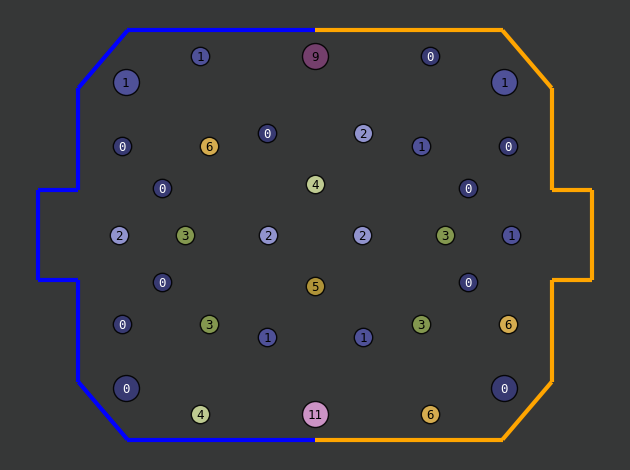

In [314]:
# step 5: make pikcup map

from scipy.spatial.distance import cdist
from matplotlib import collections  as mc

lines = [   # blue half
            [(0,-4096),(-4058,-4096)],
            [(-5120, 2944),(-5120,893)],
            [(-5120,-2944),(-5120,-893)],
            [(0,4096),(-4058,4096)],
            [(-5120,-2944),(-4058,-4096)],
            [(-5120,2944),(-4058,4096)],
            [(-6000,-893),(-6000,893)],
            [(-6000,-893),(-5120,-893)],
            [(-6000,893),(-5120,893)],
            # orange half
            [(0,-4096),(4058,-4096)],
            [(5120, 2944),(5120,893)],
            [(5120,-2944),(5120,-893)],
            [(0,4096),(4058,4096)],
            [(5120,-2944),(4058,-4096)],
            [(5120,2944),(4058,4096)],
            [(6000,-893),(6000,893)],
            [(6000,-893),(5120,-893)],
            [(6000,893),(5120,893)]
        ]

colors = ['blue']*9 + ['orange']*9

distances = cdist(pickups, pads)
labels = np.argmin(distances, axis=1)
pad_pickups = pd.Series(labels).value_counts().sort_index()

fig, ax = plt.subplots()

max_pickups = pad_pickups.max() if len(pad_pickups) > 0 else 1
norm = mpl.colors.Normalize(vmin=0, vmax=max_pickups)
cmap = mpl.cm.tab20b

for i, pad in enumerate(pads):
    count = pad_pickups[i] if i in pad_pickups.index else 0
    color = cmap(norm(count))
    if i in big_pad_inds:
        size = 350
    else:
        size = 175
    ax.scatter(pad[0], pad[1], s=size, color=color, edgecolors='black', linewidths=1, alpha=0.9)
    ax.text(pad[0], pad[1], str(count), color='black' if count > 0 else 'white', fontsize=9, 
            ha='center', va='center_baseline', fontname='monospace')

# add field lines
lc = mc.LineCollection(lines, colors=colors, linewidths=3)
ax.add_collection(lc)
ax.autoscale()

ax.axis('off')  # cleaner look
fig.patch.set_facecolor('xkcd:dark grey')
plt.tight_layout()
plt.show()

In [239]:
# step 7: compute boost stats

# Total Pickups:
print(f'Total Pickups: {len(pickups)}')

# Total Pickups by Pad Type:
small_pad_count = sum(count for i, count in pad_pickups.items() if i not in big_pad_inds)
big_pad_count = sum(count for i, count in pad_pickups.items() if i in big_pad_inds)
print(f'Total Small Pad Pickups: {small_pad_count}')
print(f'Total Big Pad Pickups: {big_pad_count}')

# Pickups by Half:
# (Does not include pads on the half-field line)
team = 0 if jim_data.pos_x.iloc[0] < 0 else 1
midfield_pickups = 0
defensive_pickups = 0
offensive_pickups = 0
for i, c in pad_pickups.items():
    if pads[i][0] == 0.0:
        midfield_pickups += pad_pickups[i] if i in pad_pickups.index else 0
    elif (pads[i][0] < 0 and team == 0) or (pads[i][0] > 0 and team == 1):
        defensive_pickups += pad_pickups[i] if i in pad_pickups.index else 0
    else:
        offensive_pickups += pad_pickups[i] if i in pad_pickups.index else 0


print(f'Total Midfield Pickups: {midfield_pickups}')
print(f'Total Defensive Pickups: {defensive_pickups}')
print(f'Total Offensive Pickups: {offensive_pickups}')


#  Total Boost Picked Up:
# (the total amount of boost picked up, regardless of whether it was usable) 
total_pickup = 0
for i, count in pad_pickups.items():
    total_pickup += count*100 if i in big_pad_inds else count*12
print(f'Total Boost Picked Up: {total_pickup}')

# total boost used
total_boost_used = (np.abs(diff[diff < 0].sum())/255)*100
print(f'﹡Total Boost Used: {total_boost_used}')
print('﹡(slightly overestimated due to frame drops and respawn logic)')

Total Pickups: 78
Total Small Pad Pickups: 56
Total Big Pad Pickups: 22
Total Midfield Pickups: 29
Total Defensive Pickups: 23
Total Offensive Pickups: 26
Total Boost Picked Up: 2872
﹡Total Boost Used: 2296.8627450980393
﹡(slightly overestimated due to frame drops and respawn logic)


# Using Boost:

In [40]:
# total boost used
total_boost_used = (np.abs(diff[diff < 0].sum())/255)*100
print(f'﹡Total Boost Used: {total_boost_used}')
print('﹡(slightly overestimated due to frame drops and respawn logic)')

﹡Total Boost Used: 2296.8627450980393
﹡(slightly overestimated due to frame drops and respawn logic)


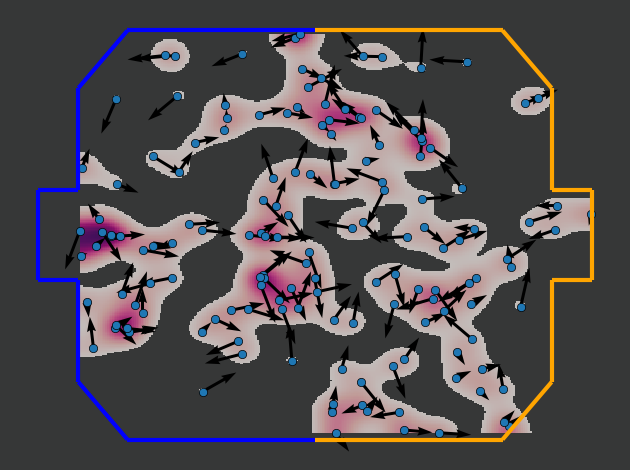

In [336]:
# step 6: boost usage map

from scipy.ndimage import gaussian_filter

lines = [   # blue half
            [(0,-4096),(-4058,-4096)],
            [(-5120, 2944),(-5120,893)],
            [(-5120,-2944),(-5120,-893)],
            [(0,4096),(-4058,4096)],
            [(-5120,-2944),(-4058,-4096)],
            [(-5120,2944),(-4058,4096)],
            [(-6000,-893),(-6000,893)],
            [(-6000,-893),(-5120,-893)],
            [(-6000,893),(-5120,893)],
            # orange half
            [(0,-4096),(4058,-4096)],
            [(5120, 2944),(5120,893)],
            [(5120,-2944),(5120,-893)],
            [(0,4096),(4058,4096)],
            [(5120,-2944),(4058,-4096)],
            [(5120,2944),(4058,4096)],
            [(6000,-893),(6000,893)],
            [(6000,-893),(5120,-893)],
            [(6000,893),(5120,893)]
        ]

colors = ['blue']*9 + ['orange']*9

boosting_loc = jim_xy[jim_xy.boost_diff < 0][['pos_x', 'pos_y']]
boosting_data = boosting_loc.join(jim_data[['vel_x', 'vel_y']], how='left')

x, y, vx, vy = boosting_data[['pos_x', 'pos_y', 'vel_x', 'vel_y']].dropna().values.T

heatmap, xedges, yedges = np.histogram2d(x, y, bins=300)
heatmap = gaussian_filter(heatmap, sigma=9.5)

threshold = np.percentile(heatmap,60)   # hide lowest X% of density
heatmap_masked = np.ma.masked_where(heatmap < threshold, heatmap)

fig, ax = plt.subplots()

# add field lines
lc = mc.LineCollection(lines, colors=colors, linewidths=3)
ax.add_collection(lc)
ax.autoscale()

plt.pcolormesh(yedges, xedges, heatmap_masked, cmap='RdPu', alpha=0.7, shading='auto')
plt.quiver(y, x, vy, vx, angles='xy', scale_units='xy', scale=28, color='black')
plt.scatter(y, x, edgecolors='black', linewidths=0.5)


plt.axis('off')
fig.patch.set_facecolor('xkcd:dark grey')
plt.tight_layout()
plt.show()